In [1]:
import pandas as pd
import json
import ir_datasets
from src.data import DATA_DIR_PROCESSED, DATA_DIR_RAW
import os
from topic_gen.evaluate import QrelsEvaluator, CohenKappa, MeanAverageError, AreaUnderReceiver, KendallTau, ROSKendallTau, ROSRBO, binarize_qrels
import ir_measures
from pathlib import Path

from topic_gen import logger
logger.setLevel("DEBUG")

In [2]:
# Load generated qrels from path
BASE_DIR = DATA_DIR_PROCESSED / "qrels"

predictions = []
predictions_graded = []
names = []
metadata_records = []
for result in os.listdir(BASE_DIR):
    names.append(result)

    # metadata
    with open(os.path.join(BASE_DIR, result, "metadata.json")) as f:
        metadata = json.load(f)
    metadata_records.append(metadata)

    # predictions
    qrels = binarize_qrels(ir_measures.read_trec_qrels(
        os.path.join(BASE_DIR, result, "qrels.csv.gz")))
    predictions.append(qrels)

    predictions_graded.append(ir_measures.read_trec_qrels(
        os.path.join(BASE_DIR, result, "qrels.csv.gz")))

In [3]:
# metadata table
metadata = pd.DataFrame(metadata_records)
metadata = metadata.join(pd.json_normalize(
    metadata["topics"]).add_prefix("topics_"))
metadata.drop(columns=["topics"], inplace=True)
metadata["topics_prompt"] = metadata["topics_prompt"].apply(
    lambda p: str(Path(p).stem) if pd.notnull(p) else "human")
metadata["prompt"] = metadata["prompt"].apply(lambda p: str(Path(p).stem))
metadata["model"] = metadata["model"].str.replace("-MT1000", "")
metadata["model"] = metadata["model"].str.replace("-MT100", "")

## Graded
This does not really apply to the Robust dataset, as only partial graded labels exist. This can be ignored for now.

In [4]:
# # Evaluate qrels
# res = QrelsEvaluator.experiment(
#     predictions=predictions_graded,
#     references=ir_datasets.load(
#         "disks45/nocr/trec-robust-2004").qrels_iter(),
#     measures=[KendallTau()],
#     bootstrap=20,
#     names=names)

In [5]:
# def format_score(row):
#     return f"{row['value']:.2f} ± {row['ci']:.2f}"


# table = pd.DataFrame(res)
# table["score"] = table.apply(format_score, axis=1)
# table = table.pivot(index="name", columns="measure",
#                     values="score").reset_index()

In [6]:
# table = table.merge(metadata, left_on="name", right_on="date")

In [7]:
# prompt_sorter = ["human", "trec", "trec-query", "trec-contrastive"]
# table["topics_prompt"] = pd.Categorical(
#     table["topics_prompt"], prompt_sorter)

# table[(table["prompt"] == "-DNA-zero-shot") & ((table["model"] == table["topics_model"]) | (table["topics_model"] == "trec assessors"))]\
#     .sort_values(by=["model", "topics_prompt"], ascending=[True, True])[["topics_prompt", "model", "topics_nqueries", "topics_ndocspos", "topics_ndocsneg", "KendallTau"]]

## Binary

In [8]:
# Evaluate qrels
res = QrelsEvaluator.experiment(
    predictions=predictions,
    references=binarize_qrels(ir_datasets.load(
        "disks45/nocr/trec-robust-2004").qrels_iter()),
    measures=[CohenKappa(), MeanAverageError(), AreaUnderReceiver()],
    bootstrap=20,
    names=names)

[topic_gen] [INFO] (evaluate.py:264) Qrels in reference but not in predictions: 12 / 2939
[topic_gen] [INFO] (evaluate.py:264) Qrels in reference but not in predictions: 8 / 2943
[topic_gen] [INFO] (evaluate.py:264) Qrels in reference but not in predictions: 0 / 2951
[topic_gen] [INFO] (evaluate.py:264) Qrels in reference but not in predictions: 11 / 2940
[topic_gen] [INFO] (evaluate.py:264) Qrels in reference but not in predictions: 4 / 2947
[topic_gen] [INFO] (evaluate.py:264) Qrels in reference but not in predictions: 10 / 2941
[topic_gen] [INFO] (evaluate.py:264) Qrels in reference but not in predictions: 24 / 2927
[topic_gen] [INFO] (evaluate.py:264) Qrels in reference but not in predictions: 0 / 2951
[topic_gen] [INFO] (evaluate.py:264) Qrels in reference but not in predictions: 0 / 2951
[topic_gen] [INFO] (evaluate.py:264) Qrels in reference but not in predictions: 2 / 2949
[topic_gen] [INFO] (evaluate.py:264) Qrels in reference but not in predictions: 15 / 2936
[topic_gen] [INF

In [10]:
def format_score(row):
    return f"{row['value']:.2f} ± {row['ci']:.2f}"


table = pd.DataFrame(res)
table["score"] = table.apply(format_score, axis=1)
table = table.pivot(index="name", columns="measure",
                    values="score").reset_index()

In [11]:
table = table.merge(metadata, left_on="name", right_on="date")

## Alignment
RQ: How well align qrels based on generated topics with the original qrels?
 

### Prompting Strategies
**Important:** the columns `ndocpos` and `ndocsneg` state values even if they are ignored by the prompts.


Prompts:
- Trec: query variants and relevant docs
- trec-query: only query
- trec-contrastive: query, relevant, and irelevant documents
  

### Findings
- Judgments based on the original topics are always better. Sometimes just a little!
- Some settings show a substantial drop in alignment, for example, for `qwen3-30B` on generated topics with the `trec` prompt with one query variant and one relevant document, the Cohen's $\kappa$ agreement to human labels drops from the substantial agreement of 0.75 to a moderate agreement of 0.52.
- More context always helps.
- Contrastive prompting is the best.

In [12]:
prompt_sorter = ["human", "trec", "trec-query", "trec-contrastive"]
table["topics_prompt"] = pd.Categorical(
    table["topics_prompt"], prompt_sorter)

table[(table["prompt"] == "-DNA-zero-shot") & ((table["model"] == table["topics_model"]) | (table["topics_model"] == "trec assessors"))]\
    .sort_values(by=["model", "topics_prompt"], ascending=[True, True])[["topics_prompt", "model", "topics_nqueries", "topics_ndocspos", "topics_ndocsneg", "CohenKappa", "MeanAverageError", "AreaUnderReceiver"]]

,topics_prompt,model,topics_nqueries,topics_ndocspos,topics_ndocsneg,CohenKappa,MeanAverageError,AreaUnderReceiver
46,human,gpt-4.1,NaN,NaN,NaN,0.64 ± 0.02,0.17 ± 0.01,0.81 ± 0.01
53,human,gpt-oss-120B,NaN,NaN,NaN,0.70 ± 0.02,0.14 ± 0.01,0.84 ± 0.01
80,human,gpt-oss-120B,NaN,NaN,NaN,0.69 ± 0.03,0.15 ± 0.01,0.84 ± 0.01
72,trec,gpt-oss-120B,1.0,1.0,3.0,0.42 ± 0.03,0.32 ± 0.01,0.74 ± 0.01
73,trec,gpt-oss-120B,3.0,2.0,3.0,0.46 ± 0.02,0.29 ± 0.01,0.76 ± 0.01
74,trec,gpt-oss-120B,5.0,3.0,3.0,0.47 ± 0.03,0.28 ± 0.01,0.76 ± 0.01
75,trec-query,gpt-oss-120B,1.0,3.0,3.0,0.33 ± 0.02,0.38 ± 0.01,0.72 ± 0.01
76,trec-query,gpt-oss-120B,3.0,3.0,3.0,0.33 ± 0.02,0.38 ± 0.02,0.72 ± 0.01
77,trec-query,gpt-oss-120B,5.0,3.0,3.0,0.40 ± 0.02,0.33 ± 0.02,0.74 ± 0.01
78,trec-contrastive,gpt-oss-120B,1.0,1.0,1.0,0.51 ± 0.03,0.26 ± 0.01,0.77 ± 0.01


In [ ]:
df = table[(table["prompt"] == "-DNA-zero-shot") & ((table["model"] == table["topics_model"]) | (table["topics_model"] == "trec assessors"))]\
    .sort_values(by=["model", "topics_prompt"], ascending=[True, True])[["topics_prompt", "model", "topics_nqueries", "topics_ndocspos", "topics_ndocsneg", "CohenKappa", "MeanAverageError", "AreaUnderReceiver"]]

df = df[(df["topics_prompt"] == "trec-contrastive")]
df["CohenKappa"] = df["CohenKappa"].apply(lambda s: float(s.split(" ± ")[0]))

In [37]:
import seaborn as sns

<Axes: xlabel='topics_nqueries', ylabel='CohenKappa'>

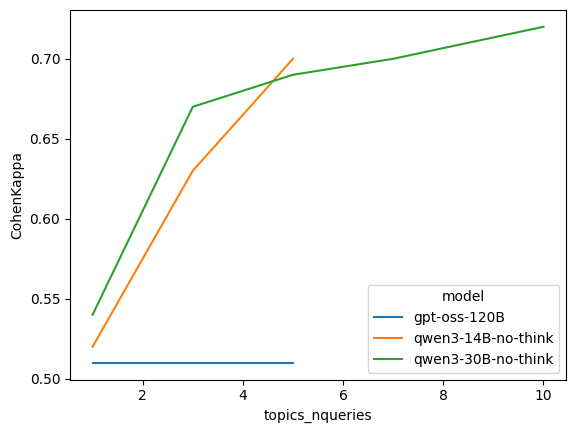

In [47]:
sns.lineplot(data=df, x="topics_nqueries", y="CohenKappa", hue="model", markers=True, dashes=False)

### Per-Topic

In [10]:
# Load generated qrels from path
BASE_DIR = DATA_DIR_PROCESSED / "qrels"

predictions = []
predictions_graded = []
names = []
metadata_records = []
for result in os.listdir(BASE_DIR):
    names.append(result)

    # metadata
    with open(os.path.join(BASE_DIR, result, "metadata.json")) as f:
        metadata = json.load(f)
    metadata_records.append(metadata)

    # predictions
    qrels = binarize_qrels(ir_measures.read_trec_qrels(
        os.path.join(BASE_DIR, result, "qrels.csv.gz")))
    predictions.append(qrels)

    predictions_graded.append(ir_measures.read_trec_qrels(
        os.path.join(BASE_DIR, result, "qrels.csv.gz")))

In [11]:
# Evaluate qrels
res = QrelsEvaluator.experiment(
    predictions=predictions,
    references=binarize_qrels(ir_datasets.load(
        "disks45/nocr/trec-robust-2004").qrels_iter()),
    measures=[CohenKappa(), MeanAverageError(), AreaUnderReceiver()],
    # bootstrap=20,
    per_query=True,
    names=names)

[topic_gen] [INFO] (evaluate.py:264) Qrels in reference but not in predictions: 12 / 2939
/home/vscode/.cache/pypoetry/virtualenvs/src-B2WAz2j2-py3.11/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/vscode/.cache/pypoetry/virtualenvs/src-B2WAz2j2-py3.11/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/vscode/.cache/pypoetry/virtualenvs/src-B2WAz2j2-py3.11/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/vscode/.cache/pypoetry/virtualenvs/src-B2WAz2j2-py3.11/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_

In [16]:
table = pd.DataFrame(res)
table = table.pivot(index=["name", "topic_id"],
                    columns="measure", values="value").reset_index()
table = table.merge(metadata, left_on="name", right_on="date")

In [18]:
table

,name,topic_id,AreaUnderReceiver,CohenKappa,MeanAverageError,date,model,data,prompt,k,...,topics_data,topics_k,topics_prompt,topics_nqueries,topics_ndocspos,topics_ndocsneg,topics_output,topics_task,topics_date,topics_s
0,2025-11-12_22:35:46,301,0.983333,0.783784,0.031250,2025-11-12_22:35:46,qwen3-30B-no-think,robust,-DNA-zero-shot,None,...,robust,None,human,NaN,NaN,NaN,NaN,topics,NaN,True
1,2025-11-12_22:35:46,302,0.900000,0.750000,0.125000,2025-11-12_22:35:46,qwen3-30B-no-think,robust,-DNA-zero-shot,None,...,robust,None,human,NaN,NaN,NaN,NaN,topics,NaN,True
2,2025-11-12_22:35:46,303,0.500000,NaN,0.200000,2025-11-12_22:35:46,qwen3-30B-no-think,robust,-DNA-zero-shot,None,...,robust,None,human,NaN,NaN,NaN,NaN,topics,NaN,True
3,2025-11-12_22:35:46,304,0.366667,-0.235294,0.388889,2025-11-12_22:35:46,qwen3-30B-no-think,robust,-DNA-zero-shot,None,...,robust,None,human,NaN,NaN,NaN,NaN,topics,NaN,True
4,2025-11-12_22:35:46,305,0.733333,0.466667,0.250000,2025-11-12_22:35:46,qwen3-30B-no-think,robust,-DNA-zero-shot,None,...,robust,None,human,NaN,NaN,NaN,NaN,topics,NaN,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28995,2025-11-17_21:56:07,696,1.000000,1.000000,0.000000,2025-11-17_21:56:07,qwen3-30B-no-think,robust,-DNA-zero-shot,None,...,robust,None,trec-contrastive,5.0,3.0,3.0,../data/processed/topics,topics,NaN,NaN
28996,2025-11-17_21:56:07,697,0.500000,NaN,0.363636,2025-11-17_21:56:07,qwen3-30B-no-think,robust,-DNA-zero-shot,None,...,robust,None,trec-contrastive,5.0,3.0,3.0,../data/processed/topics,topics,NaN,NaN
28997,2025-11-17_21:56:07,698,0.785714,0.492308,0.272727,2025-11-17_21:56:07,qwen3-30B-no-think,robust,-DNA-zero-shot,None,...,robust,None,trec-contrastive,5.0,3.0,3.0,../data/processed/topics,topics,NaN,NaN
28998,2025-11-17_21:56:07,699,1.000000,1.000000,0.000000,2025-11-17_21:56:07,qwen3-30B-no-think,robust,-DNA-zero-shot,None,...,robust,None,trec-contrastive,5.0,3.0,3.0,../data/processed/topics,topics,NaN,NaN


In [19]:
table[table["name"] == "2025-11-12_22:35:46"][["CohenKappa"]].var()

CohenKappa    0.114233
dtype: float64

In [20]:
table.groupby("name")["CohenKappa"].var()

name
2025-11-12_22:35:46    0.114233
2025-11-12_22:41:45    0.149798
2025-11-12_22:47:44    0.126039
2025-11-12_22:49:21    0.129761
2025-11-12_22:53:47    0.121797
                         ...   
2025-11-17_21:32:56    0.147240
2025-11-17_21:38:49    0.142462
2025-11-17_21:44:38    0.135309
2025-11-17_21:50:25    0.140103
2025-11-17_21:56:07    0.116609
Name: CohenKappa, Length: 117, dtype: float64